In [1]:
from ultralytics import YOLO
from pathlib import Path
import cv2
from tqdm import tqdm

In [ ]:
YOLO_MODEL = YOLO(r"..\notebooks\runs\detect\runs\YOLOv8_baseline\weights\best.pt")

DATASET = Path(r"..\dataset")

OUTPUT = Path(r"..\datasetcnn_crop_fromfile")

In [3]:
for split in ["train","val","test"]:

    for cls in ["chicken","not_chicken"]:

        (OUTPUT/split/cls).mkdir(parents=True,exist_ok=True)

In [ ]:
#cropwithyolo
OUTPUT1 = Path(r"..\datasetcnn_crop")
for split in ["train","val","test"]:

    for cls in ["chicken","not_chicken"]:

        (OUTPUT1/split/cls).mkdir(parents=True,exist_ok=True)

def crop_with_yolo(image_path):

    result = YOLO_MODEL.predict(
        source=str(image_path),
        conf=0.25,
        verbose=False
    )[0]

    image=cv2.imread(str(image_path))

    crops=[]

    for box in result.boxes:

        x1,y1,x2,y2=box.xyxy.cpu().numpy()[0]

        x1=int(max(0,x1))
        y1=int(max(0,y1))

        x2=int(x2)
        y2=int(y2)

        crop=image[y1:y2,x1:x2]

        crops.append(crop)

    return crops


for split in ["train","val","test"]:

    print(split)

    for cls in ["chicken","not_chicken"]:

        folder=DATASET/split/cls

        for image_path in tqdm(list(folder.glob("*"))):

            crops=crop_with_yolo(image_path)

            if len(crops)==0:
                continue

            for i,crop in enumerate(crops):

                save_path=OUTPUT1/split/cls/f"{image_path.stem}_{i}.jpg"

                cv2.imwrite(str(save_path),crop)

In [4]:
def yolo_to_pixels(box, image_width, image_height):

    cls, x, y, w, h = box

    x = float(x)
    y = float(y)
    w = float(w)
    h = float(h)

    x_center = x * image_width
    y_center = y * image_height

    width = w * image_width
    height = h * image_height

    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)

    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)

    x1 = max(0, x1)
    y1 = max(0, y1)

    x2 = min(image_width, x2)
    y2 = min(image_height, y2)

    return int(cls), x1, y1, x2, y2

In [5]:
for split in ["train", "val", "test"]:

    print(f"\n===== {split.upper()} =====")

    image_folder = DATASET / split / "images"
    label_folder = DATASET / split / "labels"

    print(f"Szukam obrazów w: {image_folder}")
    print(f"Folder istnieje: {image_folder.exists()}")

    images = list(image_folder.glob("*"))

    for image_path in tqdm(images):

        label_path = label_folder / (image_path.stem + ".txt")

        if not label_path.exists():
            continue

        image = cv2.imread(str(image_path))

        if image is None:
            continue

        H, W = image.shape[:2]

        with open(label_path) as f:
            lines = f.readlines()

        if len(lines) == 0:
            continue

        for i, line in enumerate(lines):

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            cls, x1, y1, x2, y2 = yolo_to_pixels(parts, W, H)

            crop = image[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            if cls == 0:
                save_dir = OUTPUT / split / "chicken"
            else:
                save_dir = OUTPUT / split / "not_chicken"

            filename = f"{image_path.stem}_{i}.jpg"

            cv2.imwrite(str(save_dir / filename), crop)


===== TRAIN =====
Szukam obrazów w: C:\Users\klanz\Desktop\MAGISTERKA\dataset\train\images
Folder istnieje: True


  0%|          | 0/4087 [00:00<?, ?it/s]

100%|██████████| 4087/4087 [00:15<00:00, 262.36it/s]



===== VAL =====
Szukam obrazów w: C:\Users\klanz\Desktop\MAGISTERKA\dataset\val\images
Folder istnieje: True


100%|██████████| 875/875 [00:03<00:00, 265.86it/s]



===== TEST =====
Szukam obrazów w: C:\Users\klanz\Desktop\MAGISTERKA\dataset\test\images
Folder istnieje: True


100%|██████████| 878/878 [00:03<00:00, 242.46it/s]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
from torch.utils.data import DataLoader
from pathlib import Path
import copy

CNN_DATASET_PATH = Path(r"..\datasetcnn_crop_fromfile")

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=str(CNN_DATASET_PATH / "train"), transform=train_transforms)
val_dataset = ImageFolder(root=str(CNN_DATASET_PATH / "val"), transform=val_test_transforms)
test_dataset = ImageFolder(root=str(CNN_DATASET_PATH / "test"), transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

model_cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model_cnn.fc.in_features
model_cnn.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = model_cnn.to(device)
print(f"Pre-trained ResNet18 przygotowany do fine-tuningu na urządzeniu: {device}")



print(f"Klasyfikator CNN przygotowany. Urządzenie obliczeniowe: {device}")
print(f"Wykryte klasy dla CNN: {train_dataset.classes}")


Pre-trained ResNet18 przygotowany do fine-tuningu na urządzeniu: cuda
Klasyfikator CNN przygotowany. Urządzenie obliczeniowe: cuda
Wykryte klasy dla CNN: ['chicken', 'not_chicken']


In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0001)

num_epochs = 100
best_val_loss = float('inf') 
patience = 20
patience_counter = 0 
best_model_wts = copy.deepcopy(model_cnn.state_dict())

print(f"Rozpoczęcie treningu modelu CNN (Maksymalnie {num_epochs} epok, Patience = {patience})...\n")

for epoch in range(num_epochs):
    model_cnn.train()
    running_loss = 0.0
    running_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_cnn(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    
    model_cnn.eval()
    val_loss = 0.0
    val_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_cnn(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = val_corrects.double() / len(val_loader.dataset)
    
    print(f"Epoka {epoch+1}/{num_epochs}:")
    print(f"  [Train] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_loss < best_val_loss - 1e-4:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model_cnn.state_dict())
        patience_counter = 0  
        print("  -> Zapisano nowe najlepsze wagi modelu.")
    else:
        patience_counter += 1 
        print(f"  -> Brak poprawy na zbiorze walidacyjnym od {patience_counter}/{patience} epok.")
        
    if patience_counter >= patience:
        print(f"\n[Early Stopping] Trening przerwany w epoce {epoch+1}. Model przestał się uczyć.")
        break

print(f"\nTrening zakończony! Najniższa strata walidacyjna (best val_loss): {best_val_loss:.4f}")

model_cnn.load_state_dict(best_model_wts)
torch.save(model_cnn.state_dict(), "best_chicken_cnn.pth")
print("Model 'best_chicken_cnn.pth' został pomyślnie zapisany na dysku.")


Rozpoczęcie treningu modelu CNN (Maksymalnie 100 epok, Patience = 20)...

Epoka 1/100:
  [Train] Loss: 0.1178 | Acc: 0.9606
  [Val]   Loss: 0.0608 | Acc: 0.9812
  -> Zapisano nowe najlepsze wagi modelu.
Epoka 2/100:
  [Train] Loss: 0.0363 | Acc: 0.9893
  [Val]   Loss: 0.0459 | Acc: 0.9875
  -> Zapisano nowe najlepsze wagi modelu.
Epoka 3/100:
  [Train] Loss: 0.0309 | Acc: 0.9902
  [Val]   Loss: 0.0824 | Acc: 0.9770
  -> Brak poprawy na zbiorze walidacyjnym od 1/20 epok.
Epoka 4/100:
  [Train] Loss: 0.0175 | Acc: 0.9943
  [Val]   Loss: 0.0618 | Acc: 0.9812
  -> Brak poprawy na zbiorze walidacyjnym od 2/20 epok.
Epoka 5/100:
  [Train] Loss: 0.0240 | Acc: 0.9923
  [Val]   Loss: 0.0500 | Acc: 0.9847
  -> Brak poprawy na zbiorze walidacyjnym od 3/20 epok.
Epoka 6/100:
  [Train] Loss: 0.0243 | Acc: 0.9927
  [Val]   Loss: 0.0713 | Acc: 0.9756
  -> Brak poprawy na zbiorze walidacyjnym od 4/20 epok.
Epoka 7/100:
  [Train] Loss: 0.0096 | Acc: 0.9975
  [Val]   Loss: 0.0408 | Acc: 0.9854
  -> Zapi

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix



In [9]:
model_cnn.eval()

pelne_predykcje = []
prawdziwe_etykiety = []

In [ ]:
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        outputs = model_cnn(inputs)
        _, preds = torch.max(outputs, 1)

        pelne_predykcje.extend(preds.cpu().numpy())
        prawdziwe_etykiety.extend(labels.numpy())


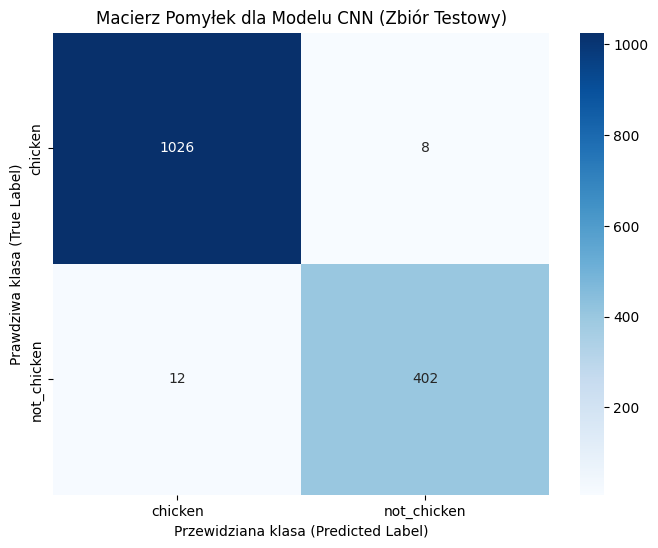

In [ ]:


nazwy_klas = train_dataset.classes 

cm = confusion_matrix(prawdziwe_etykiety, pelne_predykcje)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,         
    fmt="d",             
    cmap="Blues",       
    xticklabels=nazwy_klas, 
    yticklabels=nazwy_klas
)
plt.title("Macierz Pomyłek dla Modelu CNN (Zbiór Testowy oddany z YOLO)")
plt.ylabel("Prawdziwa klasa (True Label)")
plt.xlabel("Przewidziana klasa (Predicted Label)")
plt.show()

In [17]:
print("\n" + "="*50)
print("SZCZEGÓŁOWY RAPORT KLASYFIKACJI:")
print("="*50)
print(classification_report(prawdziwe_etykiety, pelne_predykcje, target_names=nazwy_klas))


SZCZEGÓŁOWY RAPORT KLASYFIKACJI:
              precision    recall  f1-score   support

     chicken       0.99      0.99      0.99      1034
 not_chicken       0.98      0.97      0.98       414

    accuracy                           0.99      1448
   macro avg       0.98      0.98      0.98      1448
weighted avg       0.99      0.99      0.99      1448



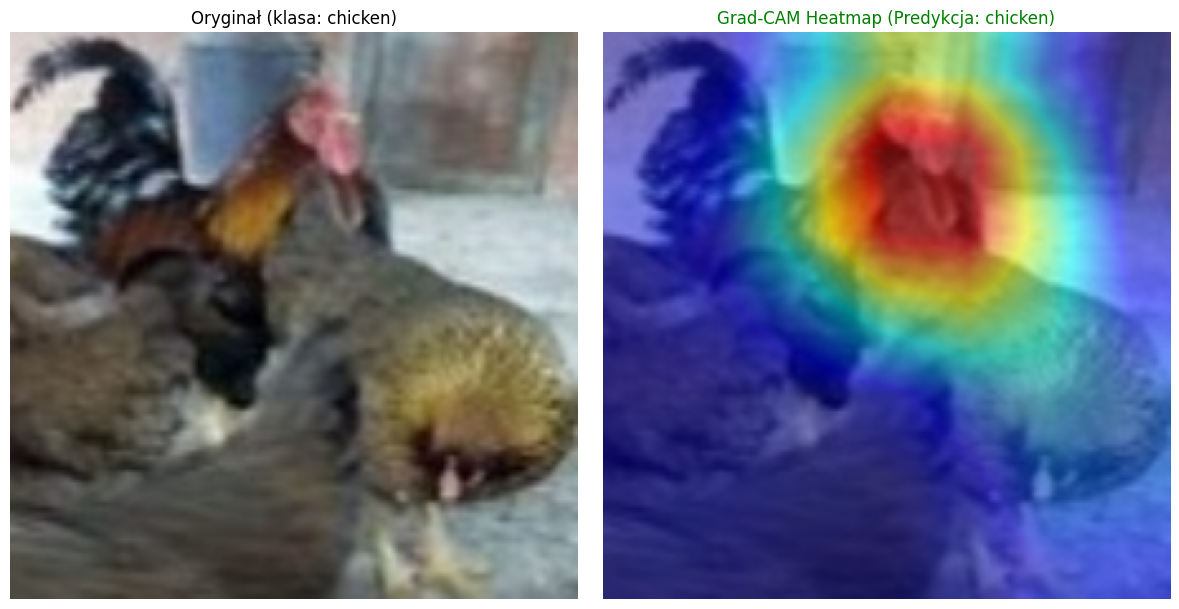

Poprawnie sklasyfikowane: 'chicken'
Heat map


In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

idx = random.randint(0, len(test_dataset) - 1)
input_tensor, label_idx = test_dataset[idx]
true_label = test_dataset.classes[label_idx]

target_layers = [model_cnn.layer4]

img_np = input_tensor.permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_rgb = np.clip(std * img_np + mean, 0, 1)

model_cnn.eval()
input_batch = input_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    output = model_cnn(input_batch)
    pred_idx = torch.argmax(output, dim=1).item()
    pred_label = test_dataset.classes[pred_idx]

targets = [ClassifierOutputTarget(pred_idx)]

with GradCAM(model=model_cnn, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_batch, targets=targets)[0, :]

visualization = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_rgb)
axes[0].set_title(f"Oryginał (klasa: {true_label})", fontsize=12)
axes[0].axis("off")

axes[1].imshow(visualization)
axes[1].set_title(
    f"Grad-CAM Heatmap (Predykcja: {pred_label})", fontsize=12, color="green" if pred_idx == label_idx else "red"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()


if pred_idx == label_idx:
    print(f"Poprawnie sklasyfikowane: '{pred_label}'")
else:
    print(f"Błędnie sklaasyfikowane: '{true_label}' jako '{pred_label}'")
print("Heat map")


In [1]:

#poniżej inna nauka CNN:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
import torchvision.models as models

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler

from pathlib import Path
import copy
import random
import numpy as np
from collections import Counter
from augumentations import AlbumentationsImageFolder


import albumentations as A

from albumentations.pytorch import ToTensorV2

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler

from pathlib import Path
from collections import Counter
import copy

c:\Users\klanz\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
CNN_DATASET_PATH = Path(r"..\datasetcnn_crop_fromfile")

RANDOM_SEED = 69

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [4]:
train_albumentations = A.Compose([

    A.RandomBrightnessContrast(brightness_limit=(-0.5, 0),contrast_limit=(-0.5, 0),p=0.5),

    A.MotionBlur(blur_limit=(3, 15),p=0.30),

    A.CoarseDropout(num_holes_range=(1, 3),hole_height_range=(0.10, 0.30),hole_width_range=(0.10, 0.30),fill=0,p=0.30),

    A.HorizontalFlip(p=0.50),

])

In [ ]:
"""from PIL import Image


class AlbumentationsImageFolder(ImageFolder):

    def __init__(self,root,transform=None):
        super().__init__(root=root,transform=None)

        self.albumentations_transform = transform


    def __getitem__(self, index):

        path, target = self.samples[index]

        image = Image.open(path).convert("RGB")

        image = np.array(image)


        if self.albumentations_transform is not None:

            augmented = self.albumentations_transform(
                image=image
            )

            image = augmented["image"]


        return image, target"""

'class AlbumentationsImageFolder(ImageFolder):\n\n    def __init__(self,root,transform=None):\n        super().__init__(root=root,transform=None)\n\n        self.albumentations_transform = transform\n\n\n    def __getitem__(self, index):\n\n        path, target = self.samples[index]\n\n        image = Image.open(path).convert("RGB")\n\n        image = np.array(image)\n\n\n        if self.albumentations_transform is not None:\n\n            augmented = self.albumentations_transform(\n                image=image\n            )\n\n            image = augmented["image"]\n\n\n        return image, target'

In [ ]:

CNN_DATASET_PATH = Path(r"..\datasetcnn_crop_fromfile")

train_transform = A.Compose([

    A.Resize(224,224),

    A.RandomBrightnessContrast(brightness_limit=(-0.5, 0),contrast_limit=(-0.5, 0),p=0.5),

    A.MotionBlur(blur_limit=(3, 15),p=0.30),

    A.CoarseDropout(num_holes_range=(1, 3),hole_height_range=(0.10, 0.30),hole_width_range=(0.10, 0.30),fill=0,p=0.30),

    A.HorizontalFlip(p=0.50),

    A.Normalize(mean=(0.485, 0.456, 0.406),std=(0.229, 0.224, 0.225)),

    ToTensorV2()
])


val_test_transform = A.Compose([

    A.Resize(224,224),

    A.Normalize(mean=(0.485, 0.456, 0.406),std=(0.229, 0.224, 0.225)),

    ToTensorV2()
])


train_dataset = AlbumentationsImageFolder(root=str(CNN_DATASET_PATH / "train"), transform=train_transform)
val_dataset = AlbumentationsImageFolder(root=str(CNN_DATASET_PATH / "val"), transform=val_test_transform)
test_dataset = AlbumentationsImageFolder(root=str(CNN_DATASET_PATH / "test"), transform=val_test_transform)

class_counts = np.bincount(
    train_dataset.targets
)

print("Liczność klas:")
for class_idx, count in enumerate(class_counts):
    print(
        f"{train_dataset.classes[class_idx]}: {count}"
    )

class_weights = 1.0 / class_counts

sample_weights = [
    class_weights[label]
    for label in train_dataset.targets
]

sample_weights = torch.DoubleTensor(
    sample_weights
)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset,batch_size=32,sampler=sampler,num_workers=2)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False,num_workers=2)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False,num_workers=2)

sampled_indices = list(
    sampler
)

sampled_labels = [
    train_dataset.targets[i]
    for i in sampled_indices
]

sampled_counts = Counter(
    sampled_labels
)

print("Przybliżona liczba próbek w jednej epoce po oversamplingu:")

for class_idx, class_name in enumerate(train_dataset.classes):
    print(
        f"{class_name}: {sampled_counts[class_idx]}"
    )

model_cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model_cnn.fc.in_features
model_cnn.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = model_cnn.to(device)
print(f"Pre-trained ResNet18 przygotowany do fine-tuningu na urządzeniu: {device}")



print(f"Klasyfikator CNN przygotowany. Urządzenie obliczeniowe: {device}")
print(f"Wykryte klasy dla CNN: {train_dataset.classes}")


Liczność klas:
chicken: 4960
not_chicken: 1889
Przybliżona liczba próbek w jednej epoce po oversamplingu:
chicken: 3407
not_chicken: 3442
Pre-trained ResNet18 przygotowany do fine-tuningu na urządzeniu: cuda
Klasyfikator CNN przygotowany. Urządzenie obliczeniowe: cuda
Wykryte klasy dla CNN: ['chicken', 'not_chicken']


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0001)

num_epochs = 100
best_val_loss = float('inf') 
patience = 20
patience_counter = 0 
best_model_wts = copy.deepcopy(model_cnn.state_dict())

print(f"Rozpoczęcie treningu modelu CNN (Maksymalnie {num_epochs} epok, Patience = {patience})...\n")

for epoch in range(num_epochs):
    model_cnn.train()
    running_loss = 0.0
    running_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_cnn(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    
    model_cnn.eval()
    val_loss = 0.0
    val_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_cnn(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = val_corrects.double() / len(val_loader.dataset)
    
    print(f"Epoka {epoch+1}/{num_epochs}:")
    print(f"  [Train] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_loss < best_val_loss - 1e-4:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model_cnn.state_dict())
        patience_counter = 0  
        print("  -> Zapisano nowe najlepsze wagi modelu.")
    else:
        patience_counter += 1 
        print(f"  -> Brak poprawy na zbiorze walidacyjnym od {patience_counter}/{patience} epok.")
        
    if patience_counter >= patience:
        print(f"\n[Early Stopping] Trening przerwany w epoce {epoch+1}. Model przestał się uczyć.")
        break

print(f"\nTrening zakończony! Najniższa strata walidacyjna (best val_loss): {best_val_loss:.4f}")

model_cnn.load_state_dict(best_model_wts)
torch.save(model_cnn.state_dict(), "best_chicken_cnn_augument2.pth")
print("Model 'best_chicken_cnn_augument2.pth' został pomyślnie zapisany na dysku.")


Rozpoczęcie treningu modelu CNN (Maksymalnie 100 epok, Patience = 20)...

Epoka 1/100:
  [Train] Loss: 0.1903 | Acc: 0.9209
  [Val]   Loss: 0.0820 | Acc: 0.9693
  -> Zapisano nowe najlepsze wagi modelu.
Epoka 2/100:
  [Train] Loss: 0.1182 | Acc: 0.9501
  [Val]   Loss: 0.0692 | Acc: 0.9777
  -> Zapisano nowe najlepsze wagi modelu.
Epoka 3/100:
  [Train] Loss: 0.1016 | Acc: 0.9594
  [Val]   Loss: 0.0574 | Acc: 0.9805
  -> Zapisano nowe najlepsze wagi modelu.
Epoka 4/100:
  [Train] Loss: 0.0918 | Acc: 0.9590
  [Val]   Loss: 0.0414 | Acc: 0.9854
  -> Zapisano nowe najlepsze wagi modelu.
Epoka 5/100:
  [Train] Loss: 0.0769 | Acc: 0.9647
  [Val]   Loss: 0.0475 | Acc: 0.9847
  -> Brak poprawy na zbiorze walidacyjnym od 1/20 epok.
Epoka 6/100:
  [Train] Loss: 0.0810 | Acc: 0.9654
  [Val]   Loss: 0.0886 | Acc: 0.9679
  -> Brak poprawy na zbiorze walidacyjnym od 2/20 epok.
Epoka 7/100:
  [Train] Loss: 0.0775 | Acc: 0.9661
  [Val]   Loss: 0.0805 | Acc: 0.9742
  -> Brak poprawy na zbiorze walidacy

In [8]:
model_cnn.eval()

pelne_predykcje = []
prawdziwe_etykiety = []

In [ ]:
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        outputs = model_cnn(inputs)
        _, preds = torch.max(outputs, 1)

        pelne_predykcje.extend(preds.cpu().numpy())
        prawdziwe_etykiety.extend(labels.numpy())

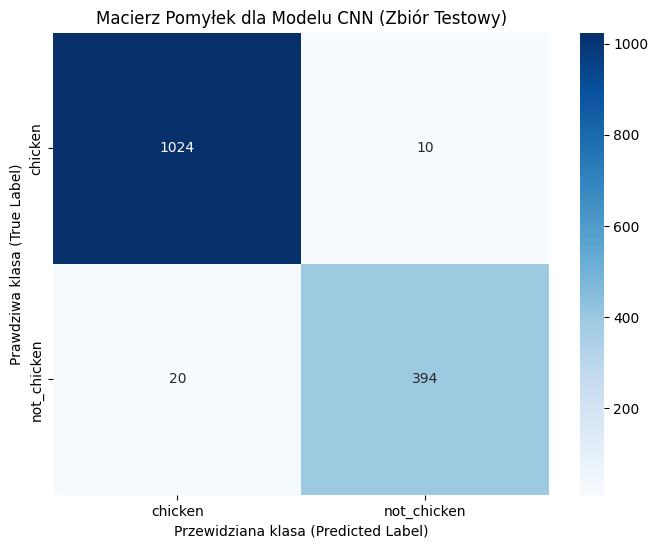

In [ ]:

nazwy_klas = train_dataset.classes 

cm = confusion_matrix(prawdziwe_etykiety, pelne_predykcje)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,         
    fmt="d",             
    cmap="Blues",       
    xticklabels=nazwy_klas, 
    yticklabels=nazwy_klas
)
plt.title("Macierz Pomyłek dla Modelu CNN (Zbiór Testowy)")
plt.ylabel("Prawdziwa klasa (True Label)")
plt.xlabel("Przewidziana klasa (Predicted Label)")
plt.show()